In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
rfm_df = pd.read_csv("../data/processed/customer_rfm_features.csv")

rfm_df["first_purchase"] = pd.to_datetime(rfm_df["first_purchase"])
rfm_df["last_purchase"] = pd.to_datetime(rfm_df["last_purchase"])

print("RFM data shape:", rfm_df.shape)

rfm_df.head()

RFM data shape: (4338, 20)


,customer_id,recency,frequency,monetary,monetary_capped,total_quantity,unique_products,avg_order_value,first_purchase,last_purchase,customer_lifetime_days,purchase_frequency_per_month,avg_quantity_per_order,monetary_per_order,product_diversity_ratio,r_score,f_score,m_score,rfm_score,rfm_segment
0,12346,326,1,77183.60,77183.600,74215,1,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,0,30.000000,74215.000000,77183.600000,0.000560,1,1,5,7,Medium Value
1,12347,2,7,4310.00,4166.600,2458,103,23.681319,2010-12-07 14:57:00,2011-12-07 15:52:00,365,0.573770,351.142857,615.714286,0.057639,5,5,5,15,Top Value
2,12348,75,4,1797.24,1770.240,2341,22,57.975484,2010-12-16 19:09:00,2011-09-25 13:13:00,282,0.424028,585.250000,449.310000,0.012311,2,4,4,10,High Value
3,12349,19,1,1757.55,1587.486,631,73,24.076027,2011-11-21 09:51:00,2011-11-21 09:51:00,0,30.000000,631.000000,1757.550000,0.040851,4,1,4,9,Medium Value
4,12350,310,1,334.40,332.032,197,17,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,30.000000,197.000000,334.400000,0.009513,1,1,2,4,Low Value


In [3]:
churn_threshold = 90

churn_df = rfm_df.copy()

churn_df["churn"] = (churn_df["recency"] > churn_threshold).astype(int)

print("Churn distribution:")
print(churn_df["churn"].value_counts())

print("\nChurn percentage:")
print(churn_df["churn"].value_counts(normalize=True) * 100)

churn_df.head()

Churn distribution:
churn
0    2889
1    1449
Name: count, dtype: int64

Churn percentage:
churn
0    66.59751
1    33.40249
Name: proportion, dtype: float64


,customer_id,recency,frequency,monetary,monetary_capped,total_quantity,unique_products,avg_order_value,first_purchase,last_purchase,...,purchase_frequency_per_month,avg_quantity_per_order,monetary_per_order,product_diversity_ratio,r_score,f_score,m_score,rfm_score,rfm_segment,churn
0,12346,326,1,77183.60,77183.600,74215,1,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,...,30.000000,74215.000000,77183.600000,0.000560,1,1,5,7,Medium Value,1
1,12347,2,7,4310.00,4166.600,2458,103,23.681319,2010-12-07 14:57:00,2011-12-07 15:52:00,...,0.573770,351.142857,615.714286,0.057639,5,5,5,15,Top Value,0
2,12348,75,4,1797.24,1770.240,2341,22,57.975484,2010-12-16 19:09:00,2011-09-25 13:13:00,...,0.424028,585.250000,449.310000,0.012311,2,4,4,10,High Value,0
3,12349,19,1,1757.55,1587.486,631,73,24.076027,2011-11-21 09:51:00,2011-11-21 09:51:00,...,30.000000,631.000000,1757.550000,0.040851,4,1,4,9,Medium Value,0
4,12350,310,1,334.40,332.032,197,17,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,...,30.000000,197.000000,334.400000,0.009513,1,1,2,4,Low Value,1


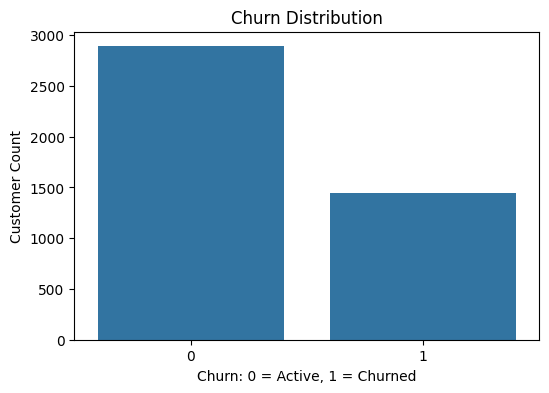

In [4]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=churn_df,
    x="churn"
)

plt.title("Churn Distribution")
plt.xlabel("Churn: 0 = Active, 1 = Churned")
plt.ylabel("Customer Count")

plt.show()

In [5]:
churn_df["is_one_time_customer"] = (churn_df["frequency"] == 1).astype(int)

churn_df["is_low_value"] = (
    churn_df["monetary"] < churn_df["monetary"].quantile(0.25)
).astype(int)

churn_df["is_high_value"] = (
    churn_df["monetary"] > churn_df["monetary"].quantile(0.75)
).astype(int)

churn_df["short_lifetime_customer"] = (
    churn_df["customer_lifetime_days"] <= 30
).astype(int)

churn_df.head()

,customer_id,recency,frequency,monetary,monetary_capped,total_quantity,unique_products,avg_order_value,first_purchase,last_purchase,...,r_score,f_score,m_score,rfm_score,rfm_segment,churn,is_one_time_customer,is_low_value,is_high_value,short_lifetime_customer
0,12346,326,1,77183.60,77183.600,74215,1,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,...,1,1,5,7,Medium Value,1,1,0,1,1
1,12347,2,7,4310.00,4166.600,2458,103,23.681319,2010-12-07 14:57:00,2011-12-07 15:52:00,...,5,5,5,15,Top Value,0,0,0,1,0
2,12348,75,4,1797.24,1770.240,2341,22,57.975484,2010-12-16 19:09:00,2011-09-25 13:13:00,...,2,4,4,10,High Value,0,0,0,1,0
3,12349,19,1,1757.55,1587.486,631,73,24.076027,2011-11-21 09:51:00,2011-11-21 09:51:00,...,4,1,4,9,Medium Value,0,1,0,1,1
4,12350,310,1,334.40,332.032,197,17,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,...,1,1,2,4,Low Value,1,1,0,0,1


In [16]:
feature_cols = [
    "frequency",
    "monetary_capped",
    "total_quantity",
    "unique_products",
    "avg_order_value",
    "customer_lifetime_days",
    "purchase_frequency_per_month",
    "avg_quantity_per_order",
    "monetary_per_order",
    "product_diversity_ratio",
    "f_score",
    "m_score",
    "is_one_time_customer",
    "is_low_value",
    "is_high_value",
    "short_lifetime_customer"
]

X = churn_df[feature_cols].copy()
y = churn_df["churn"].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (4338, 16)
y shape: (4338,)


,frequency,monetary_capped,total_quantity,unique_products,avg_order_value,customer_lifetime_days,purchase_frequency_per_month,avg_quantity_per_order,monetary_per_order,product_diversity_ratio,f_score,m_score,is_one_time_customer,is_low_value,is_high_value,short_lifetime_customer
0,1,77183.600,74215,1,77183.600000,0,30.000000,74215.000000,77183.600000,0.000560,1,5,1,0,1,1
1,7,4166.600,2458,103,23.681319,365,0.573770,351.142857,615.714286,0.057639,5,5,0,0,1,0
2,4,1770.240,2341,22,57.975484,282,0.424028,585.250000,449.310000,0.012311,4,4,0,0,1,0
3,1,1587.486,631,73,24.076027,0,30.000000,631.000000,1757.550000,0.040851,1,4,1,0,1,1
4,1,332.032,197,17,19.670588,0,30.000000,197.000000,334.400000,0.009513,1,2,1,0,0,1


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (3470, 16)
X_test: (868, 16)

Train target distribution:
churn
0    66.599424
1    33.400576
Name: proportion, dtype: float64

Test target distribution:
churn
0    66.589862
1    33.410138
Name: proportion, dtype: float64


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [19]:
rf_predictions = rf_model.predict(X_test)

rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

In [20]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print("Random Forest Results")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC AUC  :", rf_auc)

Random Forest Results
Accuracy : 0.7396313364055299
Precision: 0.626984126984127
Recall   : 0.5448275862068965
F1 Score : 0.5830258302583026
ROC AUC  : 0.8256771268345067


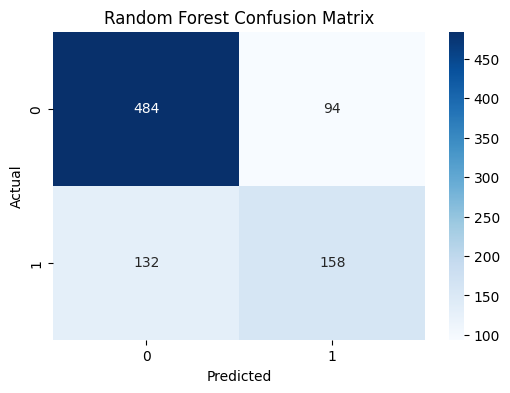

In [21]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.79      0.84      0.81       578
           1       0.63      0.54      0.58       290

    accuracy                           0.74       868
   macro avg       0.71      0.69      0.70       868
weighted avg       0.73      0.74      0.73       868



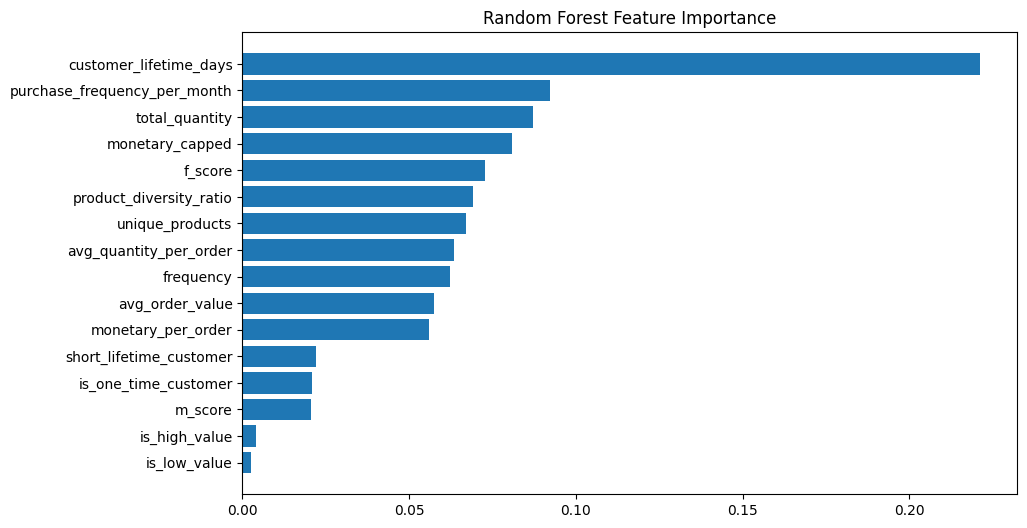

,feature,importance
5,customer_lifetime_days,0.221329
6,purchase_frequency_per_month,0.092295
2,total_quantity,0.087207
1,monetary_capped,0.080915
10,f_score,0.072702
9,product_diversity_ratio,0.069292
3,unique_products,0.066947
7,avg_quantity_per_order,0.063409
0,frequency,0.062405
4,avg_order_value,0.057373


In [23]:
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance["feature"],
    rf_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.show()

rf_importance.head(10)

XGBOOST CLASSIFIER

In [24]:
from xgboost import XGBClassifier

xgb_churn_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_churn_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [25]:
xgb_predictions = xgb_churn_model.predict(X_test)

xgb_probabilities = xgb_churn_model.predict_proba(X_test)[:, 1]

In [26]:
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)
xgb_auc = roc_auc_score(y_test, xgb_probabilities)

print("XGBoost Churn Results")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC AUC  :", xgb_auc)

XGBoost Churn Results
Accuracy : 0.7453917050691244
Precision: 0.6455696202531646
Recall   : 0.5275862068965518
F1 Score : 0.5806451612903226
ROC AUC  : 0.8262200214771507


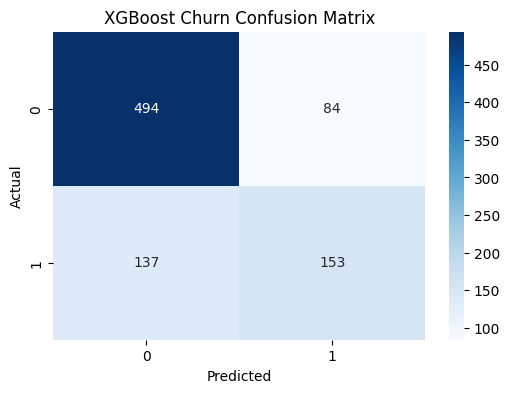

In [27]:
cm = confusion_matrix(y_test, xgb_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Churn Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.78      0.85      0.82       578
           1       0.65      0.53      0.58       290

    accuracy                           0.75       868
   macro avg       0.71      0.69      0.70       868
weighted avg       0.74      0.75      0.74       868



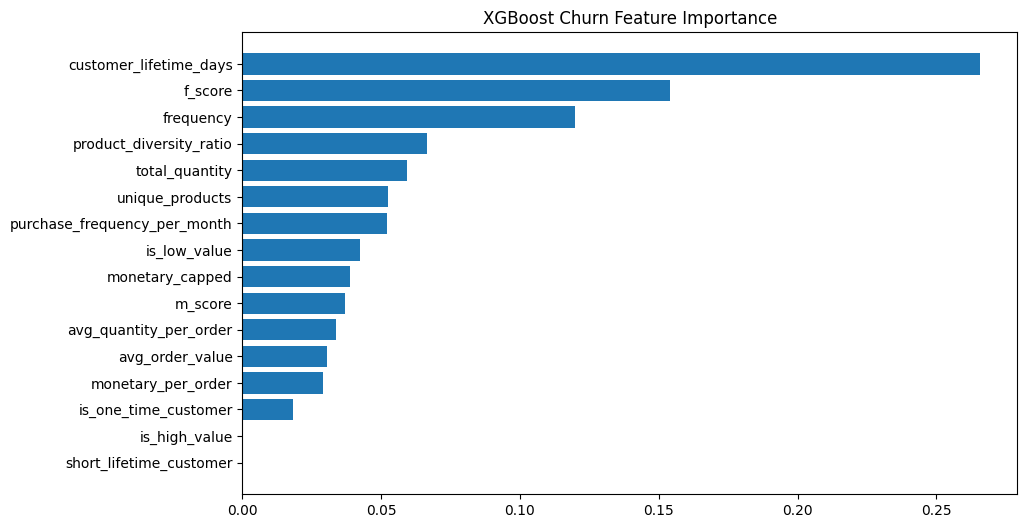

,feature,importance
5,customer_lifetime_days,0.265841
10,f_score,0.154118
0,frequency,0.119759
9,product_diversity_ratio,0.066597
2,total_quantity,0.059165
3,unique_products,0.052631
6,purchase_frequency_per_month,0.052207
13,is_low_value,0.042369
1,monetary_capped,0.038714
11,m_score,0.037050


In [29]:
xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_churn_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    xgb_importance["feature"],
    xgb_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Churn Feature Importance")

plt.show()

xgb_importance.head(10)

TUNINGGG

In [30]:
thresholds = np.arange(0.2, 0.8, 0.05)

threshold_results = []

for threshold in thresholds:
    preds = (xgb_probabilities >= threshold).astype(int)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values("f1_score", ascending=False)

,threshold,precision,recall,f1_score
3,0.35,0.558758,0.868966,0.680162
2,0.30,0.535070,0.920690,0.676806
1,0.25,0.516917,0.948276,0.669100
4,0.40,0.582245,0.768966,0.662704
0,0.20,0.494737,0.972414,0.655814
5,0.45,0.603125,0.665517,0.632787
6,0.50,0.645570,0.527586,0.580645
7,0.55,0.659341,0.413793,0.508475
8,0.60,0.688889,0.320690,0.437647
9,0.65,0.696970,0.158621,0.258427


In [31]:
best_threshold = threshold_df.sort_values(
    "f1_score",
    ascending=False
).iloc[0]["threshold"]

best_threshold

np.float64(0.35)

In [32]:
xgb_tuned_predictions = (
    xgb_probabilities >= best_threshold
).astype(int)

xgb_tuned_accuracy = accuracy_score(y_test, xgb_tuned_predictions)
xgb_tuned_precision = precision_score(y_test, xgb_tuned_predictions)
xgb_tuned_recall = recall_score(y_test, xgb_tuned_predictions)
xgb_tuned_f1 = f1_score(y_test, xgb_tuned_predictions)
xgb_tuned_auc = roc_auc_score(y_test, xgb_probabilities)

print("Threshold Tuned XGBoost Results")
print("Best Threshold:", best_threshold)
print("Accuracy :", xgb_tuned_accuracy)
print("Precision:", xgb_tuned_precision)
print("Recall   :", xgb_tuned_recall)
print("F1 Score :", xgb_tuned_f1)
print("ROC AUC  :", xgb_tuned_auc)

Threshold Tuned XGBoost Results
Best Threshold: 0.35
Accuracy : 0.7269585253456221
Precision: 0.5587583148558758
Recall   : 0.8689655172413793
F1 Score : 0.680161943319838
ROC AUC  : 0.8262200214771507


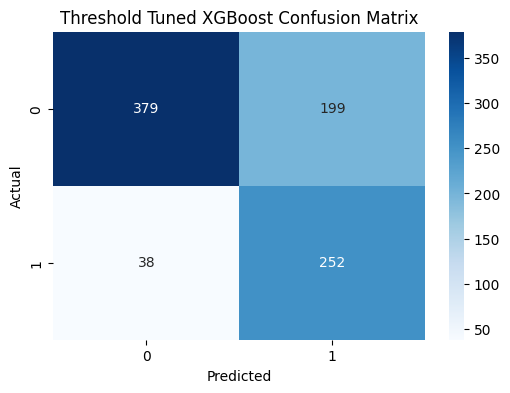

In [33]:
cm = confusion_matrix(y_test, xgb_tuned_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Threshold Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

TUNINGGG...part_2

In [34]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=40,
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV F1:")
print(random_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters:
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 1.0}
Best CV F1:
0.5582905979554915


In [35]:
xgb_tuned_model = random_search.best_estimator_

xgb_tuned_probabilities_v2 = xgb_tuned_model.predict_proba(X_test)[:, 1]
xgb_tuned_predictions_v2 = xgb_tuned_model.predict(X_test)

xgb_tuned_v2_accuracy = accuracy_score(y_test, xgb_tuned_predictions_v2)
xgb_tuned_v2_precision = precision_score(y_test, xgb_tuned_predictions_v2)
xgb_tuned_v2_recall = recall_score(y_test, xgb_tuned_predictions_v2)
xgb_tuned_v2_f1 = f1_score(y_test, xgb_tuned_predictions_v2)
xgb_tuned_v2_auc = roc_auc_score(y_test, xgb_tuned_probabilities_v2)

print("Tuned XGBoost Default Threshold Results")
print("Accuracy :", xgb_tuned_v2_accuracy)
print("Precision:", xgb_tuned_v2_precision)
print("Recall   :", xgb_tuned_v2_recall)
print("F1 Score :", xgb_tuned_v2_f1)
print("ROC AUC  :", xgb_tuned_v2_auc)

Tuned XGBoost Default Threshold Results
Accuracy : 0.7338709677419355
Precision: 0.6138996138996139
Recall   : 0.5482758620689655
F1 Score : 0.5792349726775956
ROC AUC  : 0.8221751580956926


In [36]:
thresholds = np.arange(0.20, 0.81, 0.01)

threshold_results_v2 = []

for threshold in thresholds:
    preds = (xgb_tuned_probabilities_v2 >= threshold).astype(int)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    threshold_results_v2.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

threshold_df_v2 = pd.DataFrame(threshold_results_v2)

threshold_df_v2.sort_values("f1_score", ascending=False).head(10)

,threshold,precision,recall,f1_score
14,0.34,0.555556,0.879310,0.680908
11,0.31,0.541922,0.913793,0.680359
10,0.30,0.539554,0.917241,0.679438
15,0.35,0.559020,0.865517,0.679296
12,0.32,0.544885,0.900000,0.678804
13,0.33,0.549145,0.886207,0.678100
9,0.29,0.535211,0.917241,0.675985
17,0.37,0.565421,0.834483,0.674095
7,0.27,0.527344,0.931034,0.673317
16,0.36,0.556561,0.848276,0.672131


In [37]:
best_threshold_v2 = threshold_df_v2.sort_values(
    "f1_score",
    ascending=False
).iloc[0]["threshold"]

xgb_final_predictions = (
    xgb_tuned_probabilities_v2 >= best_threshold_v2
).astype(int)

xgb_final_accuracy = accuracy_score(y_test, xgb_final_predictions)
xgb_final_precision = precision_score(y_test, xgb_final_predictions)
xgb_final_recall = recall_score(y_test, xgb_final_predictions)
xgb_final_f1 = f1_score(y_test, xgb_final_predictions)
xgb_final_auc = roc_auc_score(y_test, xgb_tuned_probabilities_v2)

print("Final Tuned XGBoost Results")
print("Best Threshold:", best_threshold_v2)
print("Accuracy :", xgb_final_accuracy)
print("Precision:", xgb_final_precision)
print("Recall   :", xgb_final_recall)
print("F1 Score :", xgb_final_f1)
print("ROC AUC  :", xgb_final_auc)

Final Tuned XGBoost Results
Best Threshold: 0.34000000000000014
Accuracy : 0.7246543778801844
Precision: 0.5555555555555556
Recall   : 0.8793103448275862
F1 Score : 0.6809078771695594
ROC AUC  : 0.8221751580956926


In [40]:
churn_model_comparison = pd.DataFrame({
    "model": [
        "Random Forest",
        "XGBoost Default",
        "Threshold-Tuned XGBoost",
        "Hyperparameter + Threshold Tuned XGBoost"
    ],
    "accuracy": [
        rf_accuracy,
        xgb_accuracy,
        xgb_tuned_accuracy,
        xgb_final_accuracy
    ],
    "precision": [
        rf_precision,
        xgb_precision,
        xgb_tuned_precision,
        xgb_final_precision
    ],
    "recall": [
        rf_recall,
        xgb_recall,
        xgb_tuned_recall,
        xgb_final_recall
    ],
    "f1_score": [
        rf_f1,
        xgb_f1,
        xgb_tuned_f1,
        xgb_final_f1
    ],
    "roc_auc": [
        rf_auc,
        xgb_auc,
        xgb_tuned_auc,
        xgb_final_auc
    ]
})

churn_model_comparison.sort_values("f1_score", ascending=False)

,model,accuracy,precision,recall,f1_score,roc_auc
3,Hyperparameter + Threshold Tuned XGBoost,0.724654,0.555556,0.879310,0.680908,0.822175
2,Threshold-Tuned XGBoost,0.726959,0.558758,0.868966,0.680162,0.826220
0,Random Forest,0.739631,0.626984,0.544828,0.583026,0.825677
1,XGBoost Default,0.745392,0.645570,0.527586,0.580645,0.826220


In [45]:
import joblib

churn_results = X_test.copy()
churn_results["actual_churn"] = y_test.values
churn_results["churn_probability"] = xgb_tuned_probabilities_v2
churn_results["predicted_churn"] = xgb_final_predictions

churn_results.to_csv(
    "../data/processed/churn_prediction_results.csv",
    index=False
)

churn_model_comparison.to_csv(
    "../data/processed/churn_model_comparison.csv",
    index=False
)

xgb_final_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_tuned_model.feature_importances_
}).sort_values("importance", ascending=False)

xgb_final_importance.to_csv(
    "../data/processed/churn_feature_importance.csv",
    index=False
)

joblib.dump(
    xgb_tuned_model,
    "../models/xgboost_churn_model.pkl"
)

joblib.dump(
    best_threshold_v2,
    "../models/xgboost_churn_threshold.pkl"
)

print("Final churn outputs saved successfully.")

Final churn outputs saved successfully.


In [46]:
print("Churn Prediction Completed Successfully!")

print("\nBest Model: Hyperparameter + Threshold Tuned XGBoost")
print("Best Threshold:", round(best_threshold_v2, 2))
print("Accuracy:", round(xgb_final_accuracy, 4))
print("Precision:", round(xgb_final_precision, 4))
print("Recall:", round(xgb_final_recall, 4))
print("F1 Score:", round(xgb_final_f1, 4))
print("ROC AUC:", round(xgb_final_auc, 4))

print("\nTop 5 Important Features:")
print(xgb_final_importance.head(5))

Churn Prediction Completed Successfully!

Best Model: Hyperparameter + Threshold Tuned XGBoost
Best Threshold: 0.34
Accuracy: 0.7247
Precision: 0.5556
Recall: 0.8793
F1 Score: 0.6809
ROC AUC: 0.8222

Top 5 Important Features:
                   feature  importance
5   customer_lifetime_days    0.466442
2           total_quantity    0.095797
3          unique_products    0.086687
10                 f_score    0.071783
0                frequency    0.063489


BLENDDD

In [49]:
# Try CatBoost first
try:
    from catboost import CatBoostClassifier

    cat_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.03,
        depth=4,
        loss_function="Logloss",
        eval_metric="F1",
        random_seed=42,
        verbose=0
    )

    cat_model.fit(X_train, y_train)

    cat_probabilities = cat_model.predict_proba(X_test)[:, 1]

    print("CatBoost trained successfully.")

except Exception as e:
    cat_model = None
    cat_probabilities = None
    print("CatBoost not available:", e)

CatBoost trained successfully.


In [50]:
if cat_probabilities is not None:
    blended_probabilities = (
        0.4 * xgb_tuned_probabilities_v2 +
        0.3 * rf_probabilities +
        0.3 * cat_probabilities
    )
else:
    blended_probabilities = (
        0.6 * xgb_tuned_probabilities_v2 +
        0.4 * rf_probabilities
    )

In [51]:
thresholds = np.arange(0.20, 0.81, 0.01)

blend_results = []

for threshold in thresholds:
    preds = (blended_probabilities >= threshold).astype(int)

    blend_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1_score": f1_score(y_test, preds)
    })

blend_threshold_df = pd.DataFrame(blend_results)

blend_threshold_df.sort_values("f1_score", ascending=False).head(10)

,threshold,precision,recall,f1_score
13,0.33,0.553419,0.893103,0.683377
14,0.34,0.559735,0.872414,0.681941
17,0.37,0.577938,0.831034,0.681754
11,0.31,0.544513,0.906897,0.680466
15,0.35,0.563348,0.858621,0.680328
10,0.30,0.539715,0.913793,0.678617
8,0.28,0.533597,0.931034,0.678392
12,0.32,0.545073,0.896552,0.677966
7,0.27,0.530214,0.937931,0.677460
9,0.29,0.535211,0.917241,0.675985


In [52]:
best_blend_threshold = blend_threshold_df.sort_values(
    "f1_score",
    ascending=False
).iloc[0]["threshold"]

blend_predictions = (
    blended_probabilities >= best_blend_threshold
).astype(int)

blend_accuracy = accuracy_score(y_test, blend_predictions)
blend_precision = precision_score(y_test, blend_predictions)
blend_recall = recall_score(y_test, blend_predictions)
blend_f1 = f1_score(y_test, blend_predictions)
blend_auc = roc_auc_score(y_test, blended_probabilities)

print("Blended Churn Model Results")
print("Best Threshold:", best_blend_threshold)
print("Accuracy :", blend_accuracy)
print("Precision:", blend_precision)
print("Recall   :", blend_recall)
print("F1 Score :", blend_f1)
print("ROC AUC  :", blend_auc)

Blended Churn Model Results
Best Threshold: 0.3300000000000001
Accuracy : 0.7235023041474654
Precision: 0.5534188034188035
Recall   : 0.8931034482758621
F1 Score : 0.683377308707124
ROC AUC  : 0.8264586564849064


SAVING MODELLL

In [53]:
churn_model_comparison.loc[len(churn_model_comparison)] = [
    "Blended XGBoost + RF + CatBoost",
    blend_accuracy,
    blend_precision,
    blend_recall,
    blend_f1,
    blend_auc
]

churn_model_comparison = churn_model_comparison.sort_values(
    "f1_score",
    ascending=False
)

churn_model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
4,Blended XGBoost + RF + CatBoost,0.723502,0.553419,0.893103,0.683377,0.826459
3,Hyperparameter + Threshold Tuned XGBoost,0.724654,0.555556,0.879310,0.680908,0.822175
2,Threshold-Tuned XGBoost,0.726959,0.558758,0.868966,0.680162,0.826220
0,Random Forest,0.739631,0.626984,0.544828,0.583026,0.825677
1,XGBoost Default,0.745392,0.645570,0.527586,0.580645,0.826220


In [54]:
import joblib

churn_results = X_test.copy()
churn_results["actual_churn"] = y_test.values
churn_results["blended_churn_probability"] = blended_probabilities
churn_results["predicted_churn"] = blend_predictions

churn_results.to_csv(
    "../data/processed/churn_prediction_results.csv",
    index=False
)

churn_model_comparison.to_csv(
    "../data/processed/churn_model_comparison.csv",
    index=False
)

joblib.dump(xgb_tuned_model, "../models/xgboost_churn_model.pkl")
joblib.dump(rf_model, "../models/random_forest_churn_model.pkl")

if cat_model is not None:
    joblib.dump(cat_model, "../models/catboost_churn_model.pkl")

joblib.dump(best_blend_threshold, "../models/blended_churn_threshold.pkl")

print("Final blended churn outputs saved successfully.")

Final blended churn outputs saved successfully.


In [55]:
print("Churn Prediction Completed Successfully!")

print("\nBest Model: Blended XGBoost + Random Forest + CatBoost")
print("Best Threshold:", round(best_blend_threshold, 2))
print("Accuracy:", round(blend_accuracy, 4))
print("Precision:", round(blend_precision, 4))
print("Recall:", round(blend_recall, 4))
print("F1 Score:", round(blend_f1, 4))
print("ROC AUC:", round(blend_auc, 4))

Churn Prediction Completed Successfully!

Best Model: Blended XGBoost + Random Forest + CatBoost
Best Threshold: 0.33
Accuracy: 0.7235
Precision: 0.5534
Recall: 0.8931
F1 Score: 0.6834
ROC AUC: 0.8265
